In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split, WeightedRandomSampler
from torch.optim.lr_scheduler import StepLR

from tqdm import tqdm

import torchvision

import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms


!pip install torchmetrics
from torchmetrics import Accuracy

import time

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [17]:
# Load training dataset
training_file = 'train.pt'
training_data = torch.load(training_file, map_location = device)
training_waveforms = training_data['raw waves']
training_depth     = training_data['depth labels']
training_mag       = training_data['mag labels']
training_loc       = training_data['loc class']
training_origin    = training_data['origin class']

depth_targets  = torch.argmax(torch.squeeze(training_depth, dim=1),    dim = 1)
mag_targets    = torch.argmax(torch.squeeze(training_mag, dim = 1),    dim = 1)
loc_targets    = torch.argmax(torch.squeeze(training_loc, dim = 1),    dim = 1)
origin_targets = torch.argmax(torch.squeeze(training_origin, dim = 1), dim = 1)

trainingset = TensorDataset(training_waveforms, training_depth, training_mag, training_loc, training_origin)
training = DataLoader(trainingset, batch_size=16, shuffle=True)

# Load test dataset
testing_file  = 'test.pt'
testing_data  = torch.load(testing_file, map_location = device)
testing_waveforms = testing_data['raw waves']
testing_depth     = testing_data['depth labels']
testing_mag       = testing_data['mag labels']
testing_loc       = testing_data['loc class']
testing_origin    = testing_data['origin class']
testingset  = TensorDataset(testing_waveforms, testing_depth, testing_mag, testing_loc, testing_origin)
testing     = DataLoader(testingset, batch_size=16, shuffle = False)

In [18]:
classes = 3

# Define Model
class CNN(nn.Module):

    def __init__(self, num_features):
        super(CNN, self).__init__()

        self.conv1   = nn.Conv2d(1,    out_channels = 16,  kernel_size =(3,3), padding ='same')
        self.conv2   = nn.Conv2d(16,   out_channels = 64,  kernel_size =(3,3), padding ='same')
        self.conv3   = nn.Conv2d(64,   out_channels = 64,  kernel_size =(3,3), padding ='same')
        self.conv4   = nn.Conv2d(64,   out_channels = 128, kernel_size =(3,3), padding ='same')
        self.conv5   = nn.Conv2d(128,  out_channels = 256, kernel_size =(3,3), padding ='same')
        self.pool    = nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 1)
        self.bn1     = nn.BatchNorm2d(16)
        self.bn2     = nn.BatchNorm2d(64)
        self.bn3     = nn.BatchNorm2d(64)
        self.bn4     = nn.BatchNorm2d(128)
        self.bn5     = nn.BatchNorm2d(256)
        self.relu    = nn.ReLU()
        self.softmax = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(p=0.2)

        self.fullyconnected1 = nn.LazyLinear(8192)
        self.fullyconnected2 = nn.LazyLinear(classes)
        self.fullyconnected3 = nn.LazyLinear(classes)
        self.fullyconnected4 = nn.LazyLinear(classes)
        self.fullyconnected5 = nn.LazyLinear(classes)

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)

        x = self.conv5(x)
        x = self.bn5(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)

        x = torch.flatten(x, start_dim = 1)
        features = self.fullyconnected1(x)
        depth = self.fullyconnected2(features)
        mag = self.fullyconnected3(features)
        loc = self.fullyconnected4(features)
        origin = self.fullyconnected5(features)

        return depth, mag, loc, origin

In [19]:
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)

In [20]:
# Construct model
model = CNN(classes)
model.to(device)

# define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion_depth  = nn.CrossEntropyLoss(weight = torch.tensor([5.00, 0.61, 0.85]).to(device))
criterion_mag    = nn.CrossEntropyLoss(weight = torch.tensor([0.83, 0.58, 15.4]).to(device))
criterion_loc    = nn.CrossEntropyLoss(weight = torch.tensor([0.78, 1.00, 1.37]).to(device))
criterion_origin = nn.CrossEntropyLoss(weight = torch.tensor([0.42, 4.06, 2.58]).to(device))

print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv2): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (softmax): Softmax(dim=-1)
  (dropout): Dropout(p=0.2, inplace=Fals

In [21]:
epochs=50
model.train()

training_accuracies_depth = []
training_accuracies_mag = []
training_accuracies_loc = []
training_accuracies_origin = []
avg_losses = []

training_accuracies_depth  = []
training_accuracies_mag    = []
training_accuracies_loc    = []
training_accuracies_origin = []

start_time = time.perf_counter()

# Training Loop
for epoch in range(epochs):

    print(f"Epoch [{epoch + 1}/{epochs}]")

    acc_depth_training = Accuracy(task="multiclass", num_classes = classes).to(device)
    acc_mag_training = Accuracy(task="multiclass", num_classes = classes).to(device)
    acc_loc_training = Accuracy(task="multiclass", num_classes = classes).to(device)
    acc_origin_training = Accuracy(task="multiclass", num_classes = classes).to(device)

    all_preds_depth_training = []
    all_labels_depth_training = []
    all_preds_mag_training = []
    all_labels_mag_training = []
    all_preds_loc_training = []
    all_labels_loc_training = []
    all_preds_origin_training = []
    all_labels_origin_training = []

    batch_losses = []
    avg_depth_accuracy = []
    avg_mag_accuracy = []
    avg_loc_accuracy = []
    avg_origin_accuracy = []

    for i, data in enumerate(training):


        raw_data, depth_labels, mag_labels, loc_labels, origin_labels = data

        depth_labels = torch.squeeze(depth_labels)
        mag_labels = torch.squeeze(mag_labels)
        loc_labels = torch.squeeze(loc_labels)
        origin_labels = torch.squeeze(origin_labels)
        _, depth_truth = torch.max(depth_labels, 1)
        _, mag_truth   = torch.max(mag_labels, 1)
        _, loc_truth   = torch.max(loc_labels, 1)
        _, origin_truth = torch.max(origin_labels, 1)

        depth_classification, mag_classification, location_classification, origin_classification = model(raw_data.float())

        _, depth_preds = torch.max(depth_classification, 1)
        _, mag_preds = torch.max(mag_classification, 1)
        _, loc_preds = torch.max(location_classification, 1)
        _, origin_preds = torch.max(origin_classification, 1)

        loss = criterion_depth(depth_classification, depth_truth)
        loss += criterion_mag(mag_classification, mag_truth)
        loss += criterion_loc(location_classification, loc_truth)
        loss += (criterion_origin(origin_classification, origin_truth))

        batch_losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        all_preds_depth_training.extend(depth_preds.cpu().numpy())
        all_labels_depth_training.extend(depth_truth.cpu().numpy())
        all_preds_mag_training.extend(mag_preds.cpu().numpy())
        all_labels_mag_training.extend(mag_truth.cpu().numpy())
        all_preds_loc_training.extend(loc_preds.cpu().numpy())
        all_labels_loc_training.extend(loc_truth.cpu().numpy())
        all_preds_origin_training.extend(origin_preds.cpu().numpy())
        all_labels_origin_training.extend(origin_truth.cpu().numpy())

        acc_depth_training(depth_preds, depth_truth)
        acc_mag_training(mag_preds, mag_truth)
        acc_loc_training(loc_preds, loc_truth)
        acc_origin_training(origin_preds, origin_truth)

    train_accuracy_depth = acc_depth_training.compute()
    train_accuracy_mag = acc_mag_training.compute()
    train_accuracy_loc = acc_loc_training.compute()
    train_accuracy_origin = acc_origin_training.compute()


    avg_losses.append(np.mean(batch_losses))
    training_accuracies_depth.append(train_accuracy_depth.cpu().item())
    training_accuracies_mag.append(train_accuracy_mag.cpu().item())
    training_accuracies_loc.append(train_accuracy_loc.cpu().item())
    training_accuracies_origin.append(train_accuracy_origin.cpu().item())
    print(f"Average loss: {np.mean(batch_losses)}")

end_time = time.perf_counter()
print(f"Training time: {end_time - start_time}")

Epoch [1/50]
Average loss: 29.329701813173966
Epoch [2/50]
Average loss: 4.508800142247912
Epoch [3/50]
Average loss: 4.746502139198948
Epoch [4/50]
Average loss: 4.457726162923893
Epoch [5/50]
Average loss: 4.282948242106908
Epoch [6/50]
Average loss: 4.425677334758597
Epoch [7/50]
Average loss: 4.070901271323083
Epoch [8/50]
Average loss: 3.72717633045895
Epoch [9/50]
Average loss: 3.49526129642003
Epoch [10/50]
Average loss: 3.196621020075301
Epoch [11/50]
Average loss: 3.0256991201723125
Epoch [12/50]
Average loss: 2.8196007290356597
Epoch [13/50]
Average loss: 2.6260022529414004
Epoch [14/50]
Average loss: 2.490581431019474
Epoch [15/50]
Average loss: 2.527945789652811
Epoch [16/50]
Average loss: 2.4577195350552947
Epoch [17/50]
Average loss: 2.2855131248353233
Epoch [18/50]
Average loss: 2.240378857498438
Epoch [19/50]
Average loss: 2.1414394538167496
Epoch [20/50]
Average loss: 2.1425545626962688
Epoch [21/50]
Average loss: 2.3140804591313215
Epoch [22/50]
Average loss: 2.020644

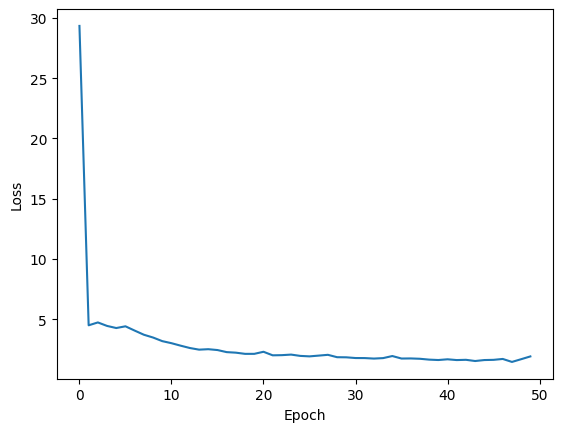

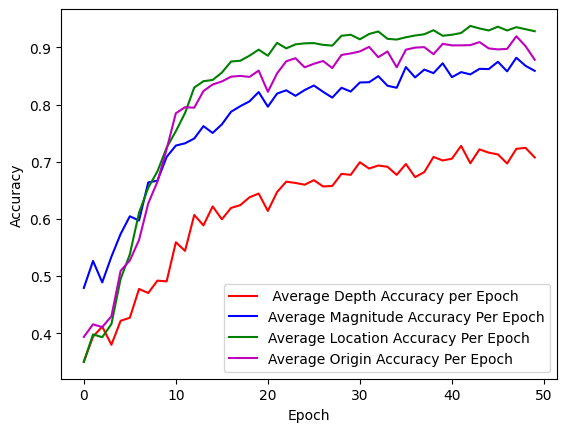

Depth Accuracy: 0.7075971961021423
Magnitude Accuracy: 0.8590989112854004
Location Accuracy: 0.9284452199935913
Origin Accuracy: 0.8785335421562195


In [22]:
plt.figure()
avg_losses = np.array(avg_losses)
plt.plot(avg_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
training_accuracies_depth = np.array(training_accuracies_depth)
training_accuracies_mag = np.array(training_accuracies_mag)
training_accuracies_loc = np.array(training_accuracies_loc)
training_accuracies_origin = np.array(training_accuracies_origin)
plt.plot(training_accuracies_depth,  color = 'red', label = " Average Depth Accuracy per Epoch")
plt.plot(training_accuracies_mag,    color = "b",   label = "Average Magnitude Accuracy Per Epoch")
plt.plot(training_accuracies_loc,    color = "g",   label = "Average Location Accuracy Per Epoch")
plt.plot(training_accuracies_origin, color = "m",   label = "Average Origin Accuracy Per Epoch")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

print(f"Depth Accuracy: {training_accuracies_depth[-1]}")
print(f"Magnitude Accuracy: {training_accuracies_mag[-1]}")
print(f"Location Accuracy: {training_accuracies_loc[-1]}")
print(f"Origin Accuracy: {training_accuracies_origin[-1]}")

Testing time: 0.6028046149999682
Avg time per EQ: 0.0006220893859648795
Depth test accuracy: 0.7172342538833618
Magnitude test accuracy: 0.8462332487106323
Location test accuracy: 0.932920515537262
Origin test accuracy: 0.9060887694358826
Depth Confusion Matrix
Mag Confusion Matrix
Location Confusion Matrix
Origin Confusion Matrix


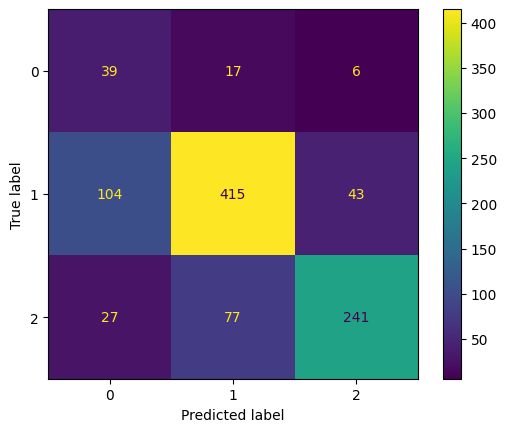

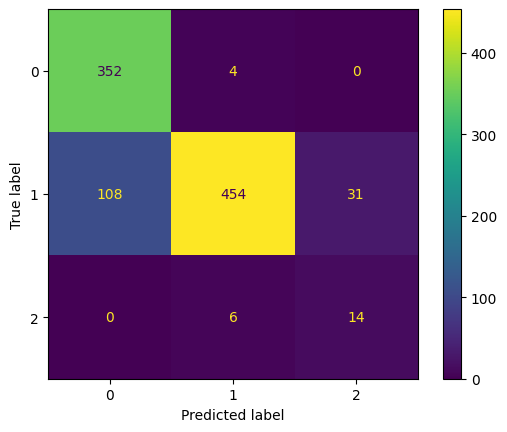

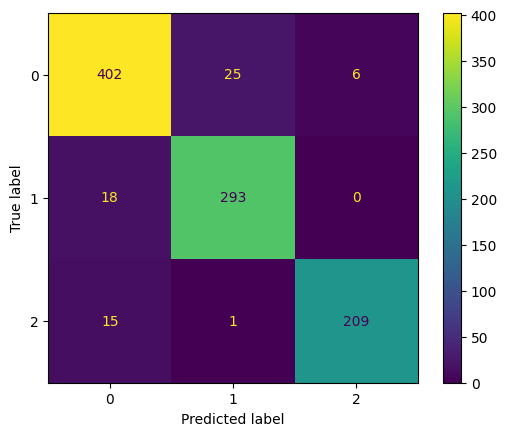

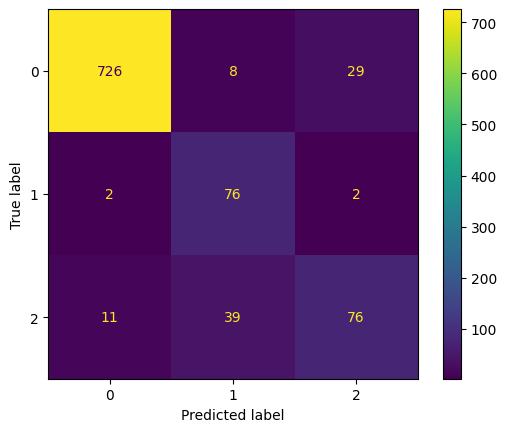

In [23]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Testing
acc_depth = Accuracy(task="multiclass", num_classes = classes).to(device)
acc_mag = Accuracy(task="multiclass", num_classes = classes).to(device)
acc_loc = Accuracy(task="multiclass", num_classes = classes).to(device)
acc_origin = Accuracy(task="multiclass", num_classes = classes).to(device)
model.eval()

all_preds_depth = []
all_labels_depth = []
all_preds_mag = []
all_labels_mag = []
all_preds_loc = []
all_labels_loc = []
all_preds_origin = []
all_labels_origin = []
with torch.no_grad():

   start_test_time = time.perf_counter()
   for i, data in enumerate(testing):

       raw_data, depth_labels, mag_labels, loc_labels, origin_labels = data
       depth_labels = torch.squeeze(depth_labels, dim = 1)
       mag_labels = torch.squeeze(mag_labels, dim = 1)
       loc_labels = torch.squeeze(loc_labels, dim = 1)
       origin_labels = torch.squeeze(origin_labels, dim = 1)
       depth_class, mag_class, loc_class, origin_class = model(raw_data.float())
       _, depth_preds = torch.max(depth_class, 1)
       _, depth_truth = torch.max(depth_labels, 1)
       _, mag_preds = torch.max(mag_class, 1)
       _, mag_truth = torch.max(mag_labels, 1)
       _, loc_preds = torch.max(loc_class, 1)
       _, loc_truth = torch.max(loc_labels, 1)
       _, origin_preds = torch.max(origin_class, 1)
       _, origin_truth = torch.max(origin_labels, 1)

       all_preds_depth.extend(depth_preds.cpu().numpy())
       all_labels_depth.extend(depth_truth.cpu().numpy())
       all_preds_mag.extend(mag_preds.cpu().numpy())
       all_labels_mag.extend(mag_truth.cpu().numpy())
       all_preds_loc.extend(loc_preds.cpu().numpy())
       all_labels_loc.extend(loc_truth.cpu().numpy())
       all_preds_origin.extend(origin_preds.cpu().numpy())
       all_labels_origin.extend(origin_truth.cpu().numpy())

       acc_depth(depth_preds, depth_truth)
       acc_mag(mag_preds, mag_truth)
       acc_loc(loc_preds, loc_truth)
       acc_origin(origin_preds, origin_truth)
end_test_time = time.perf_counter()
time_lapse = end_test_time - start_test_time
print(f"Testing time: {end_test_time - start_test_time}")
print(f"Avg time per EQ: {(time_lapse/969)}")

test_accuracy_depth = acc_depth.compute()
test_accuracy_mag = acc_mag.compute()
test_accuracy_loc = acc_loc.compute()
test_accuracy_origin = acc_origin.compute()
print(f"Depth test accuracy: {test_accuracy_depth}")
print(f"Magnitude test accuracy: {test_accuracy_mag}")
print(f"Location test accuracy: {test_accuracy_loc}")
print(f"Origin test accuracy: {test_accuracy_origin}")


cm_depth = confusion_matrix(all_labels_depth, all_preds_depth)
cm_mag   = confusion_matrix(all_labels_mag, all_preds_mag)
cm_loc   = confusion_matrix(all_labels_loc, all_preds_loc)
cm_origin = confusion_matrix(all_labels_origin, all_preds_origin)

print(f"Depth Confusion Matrix")
disp_depth = ConfusionMatrixDisplay(confusion_matrix=cm_depth)
disp_depth.plot()

print(f"Mag Confusion Matrix")
disp_mag = ConfusionMatrixDisplay(confusion_matrix=cm_mag)
disp_mag.plot()

print(f"Location Confusion Matrix")
disp_loc = ConfusionMatrixDisplay(confusion_matrix=cm_loc)
disp_loc.plot()

print(f"Origin Confusion Matrix")
disp_origin = ConfusionMatrixDisplay(confusion_matrix=cm_origin)
disp_origin.plot()

In [24]:
torch.save(model.state_dict(), "CNN_All4_model.pth")